# Lab 06: CNN on CIFAR-10 (Zarmeena Jawad)

**Course:** COMP-341L - Artificial Neural Networks Lab  
**Student:** Zarmeena Jawad  
**Roll Number:** B23F0115AI125  
**Section:** AI Red  
**Execution Environment:** Google Colab only (no local installation on macOS)

This notebook implements all required tasks from Lab 06 (Tasks 1-8).

In [1]:
# Optional: Mount Google Drive for persistent saving.
# Keep commented if you are not using Drive.
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from datetime import datetime

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set this to a Google Drive folder for persistent outputs in Colab.
# Example:
# BASE_DIR = '/content/drive/MyDrive/COMP-341L/Lab 6/Zarmeena Jawad's Lab'
BASE_DIR = os.environ.get('LAB6_BASE_DIR', '.')
PLOTS_DIR = os.path.join(BASE_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 64

print('TensorFlow version:', tf.__version__)
print('BASE_DIR:', os.path.abspath(BASE_DIR))
print('PLOTS_DIR:', os.path.abspath(PLOTS_DIR))


TensorFlow version: 2.19.0
Plots directory: ./plots


## Task 1: Load and Explore the CIFAR-10 Dataset
- Display dataset shape
- Show at least 10 sample images
- Visualize class names

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000, 1)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipython-input-1752/175424818.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(y_train[i])])


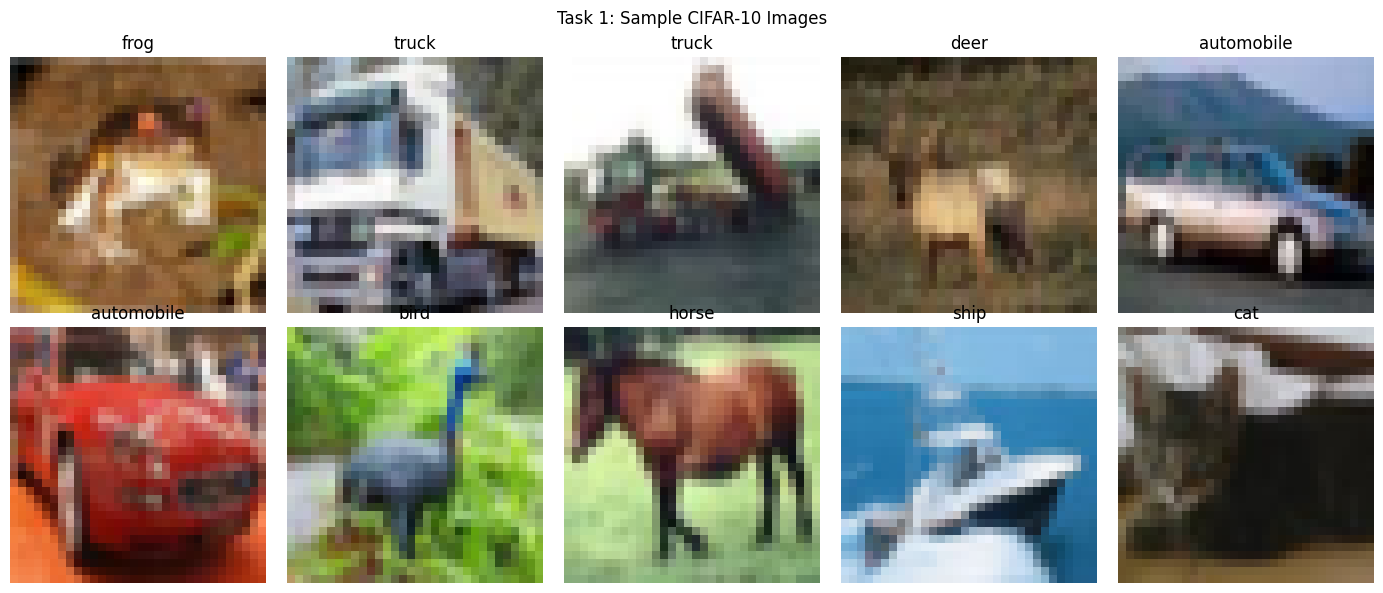

Saved: ./plots/task1_sample_images.png


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)
print('Class names:', class_names)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train[i])])
    ax.axis('off')
plt.suptitle('Task 1: Sample CIFAR-10 Images')
plt.tight_layout()
sample_path = os.path.join(PLOTS_DIR, 'task1_sample_images.png')
plt.savefig(sample_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', sample_path)

## Task 2: Preprocess the Data
- Normalize pixel values
- Convert labels if required

In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = y_train.squeeze().astype('int64')
y_test = y_test.squeeze().astype('int64')

print('After preprocessing:')
print('x_train min/max:', x_train.min(), x_train.max())
print('x_test min/max :', x_test.min(), x_test.max())
print('y_train shape  :', y_train.shape)
print('y_test shape   :', y_test.shape)
print('Using sparse labels with sparse_categorical_crossentropy, so one-hot encoding is optional here.')

After preprocessing:
x_train min/max: 0.0 1.0
x_test min/max : 0.0 1.0
y_train shape  : (50000,)
y_test shape   : (10000,)
Using sparse labels with sparse_categorical_crossentropy, so one-hot encoding is optional here.


## Task 3: Build a CNN Model
Requirements satisfied:
- At least 2 Conv layers
- ReLU activations
- MaxPooling
- Dropout
- Dense layers
- Softmax output

In [5]:
        def build_model(input_shape=(32, 32, 3), num_classes=10):
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=input_shape),
                tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
                tf.keras.layers.MaxPooling2D((2, 2)),

                tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
                tf.keras.layers.MaxPooling2D((2, 2)),

                tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
                tf.keras.layers.MaxPooling2D((2, 2)),

                tf.keras.layers.Flatten(),
                tf.keras.layers.Dense(256, activation='relu'),
                tf.keras.layers.Dropout(0.40),
                tf.keras.layers.Dense(num_classes, activation='softmax'),
            ], name='cifar10_cnn_zarmeena')
            return model


model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "cifar10_cnn_zarmeena"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Train the CNN
- Train for at least 10 epochs
- Show training/validation accuracy and loss

In [6]:
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1,
)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f'Final Training Accuracy   : {final_train_acc:.4f}')
print(f'Final Validation Accuracy : {final_val_acc:.4f}')
print(f'Final Training Loss       : {final_train_loss:.4f}')
print(f'Final Validation Loss     : {final_val_loss:.4f}')

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 341ms/step - accuracy: 0.3490 - loss: 1.7606 - val_accuracy: 0.5634 - val_loss: 1.2042
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 249s 322ms/step - accuracy: 0.5868 - loss: 1.1568 - val_accuracy: 0.6558 - val_loss: 0.9732
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 329ms/step - accuracy: 0.6599 - loss: 0.9582 - val_accuracy: 0.7082 - val_loss: 0.8345
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 221s 313ms/step - accuracy: 0.7071 - loss: 0.8371 - val_accuracy: 0.7296 - val_loss: 0.7769
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 233s 331ms/step - accuracy: 0.7309 - loss: 0.7581 - val_accuracy: 0.7460 - val_loss: 0.7414
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 220s 312ms/step - accuracy: 0.7629 - loss: 0.6792 - val_accuracy: 0.7442 - val_loss: 0.7514
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 235s 334ms/step - accuracy: 0.7799 - loss: 0.6202 - val_accuracy: 0.7286 - val_loss: 0.8100
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 341ms/step - accuracy: 0.7991 -

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/COMP-341L/Lab 6/Zarmeena Jawad's Lab"
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("PLOTS_DIR:", PLOTS_DIR)

## Task 5: Evaluate the Model
- Compute test accuracy
- Show confusion matrix
- Display classification report

Test Accuracy: 0.7424
Test Loss    : 0.8265


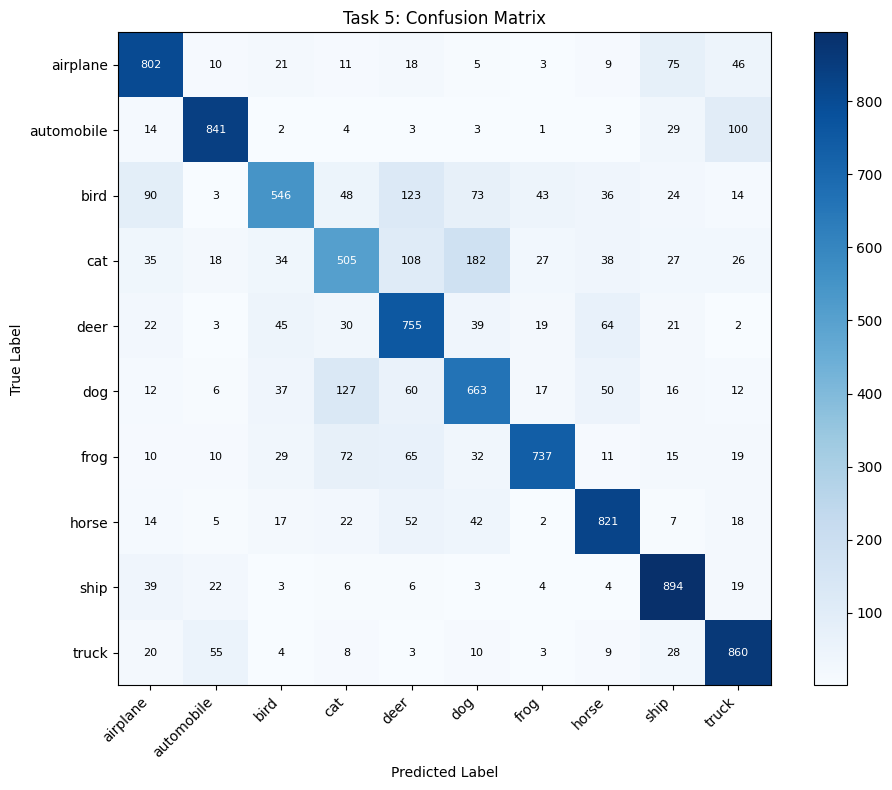

Saved: ./plots/task5_confusion_matrix.png

Classification Report:

              precision    recall  f1-score   support

    airplane     0.7580    0.8020    0.7794      1000
  automobile     0.8643    0.8410    0.8525      1000
        bird     0.7398    0.5460    0.6283      1000
         cat     0.6062    0.5050    0.5510      1000
        deer     0.6329    0.7550    0.6886      1000
         dog     0.6302    0.6630    0.6462      1000
        frog     0.8610    0.7370    0.7942      1000
       horse     0.7856    0.8210    0.8029      1000
        ship     0.7870    0.8940    0.8371      1000
       truck     0.7706    0.8600    0.8129      1000

    accuracy                         0.7424     10000
   macro avg     0.7436    0.7424    0.7393     10000
weighted avg     0.7436    0.7424    0.7393     10000

Saved: ./plots/task5_classification_report.txt


In [8]:
# Evaluate on test set and print metrics
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss    : {test_loss:.4f}')

# Model prediction
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Ensure y_test is 1D (required by confusion_matrix/classification_report)
if y_test.ndim > 1:
    y_test_flat = y_test.flatten()
else:
    y_test_flat = y_test

# Confusion matrix
cm = confusion_matrix(y_test_flat, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set_title('Task 5: Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black', fontsize=8)
plt.tight_layout()
cm_path = os.path.join(PLOTS_DIR, 'task5_confusion_matrix.png')
plt.savefig(cm_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', cm_path)

# Classification report
report_text = classification_report(y_test_flat, y_pred, target_names=class_names, digits=4)
print('\nClassification Report:\n')
print(report_text)

report_path = os.path.join(PLOTS_DIR, 'task5_classification_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)
print('Saved:', report_path)

## Task 6: Make Predictions
- Pick 5 random CIFAR-10 test images
- Show actual and predicted labels

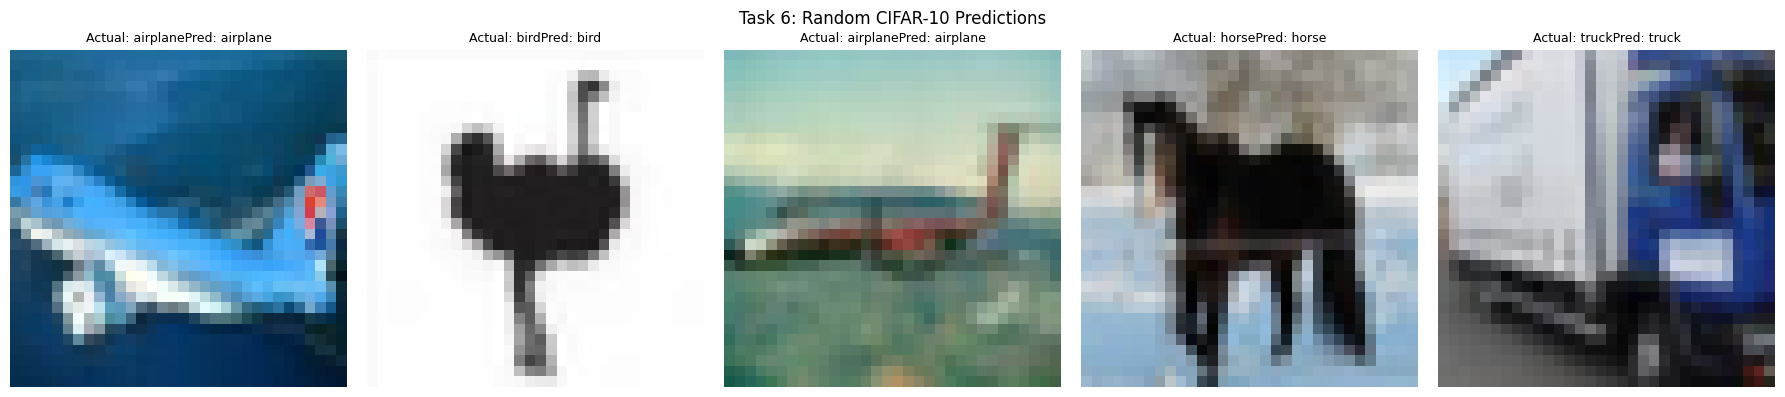

Saved: ./plots/task6_random_predictions.png


In [10]:
rng = np.random.default_rng(SEED)
indices = rng.choice(len(x_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, idx in zip(axes, indices):
    ax.imshow(x_test[idx])
    actual = class_names[int(y_test[idx])]
    pred = class_names[int(y_pred[idx])]
    ax.set_title(f'Actual: {actual}Pred: {pred}', fontsize=9)
    ax.axis('off')

plt.suptitle('Task 6: Random CIFAR-10 Predictions')
plt.tight_layout()
pred_path = os.path.join(PLOTS_DIR, 'task6_random_predictions.png')
plt.savefig(pred_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', pred_path)

## Task 7: Plot Results
- Training vs validation accuracy
- Training vs validation loss

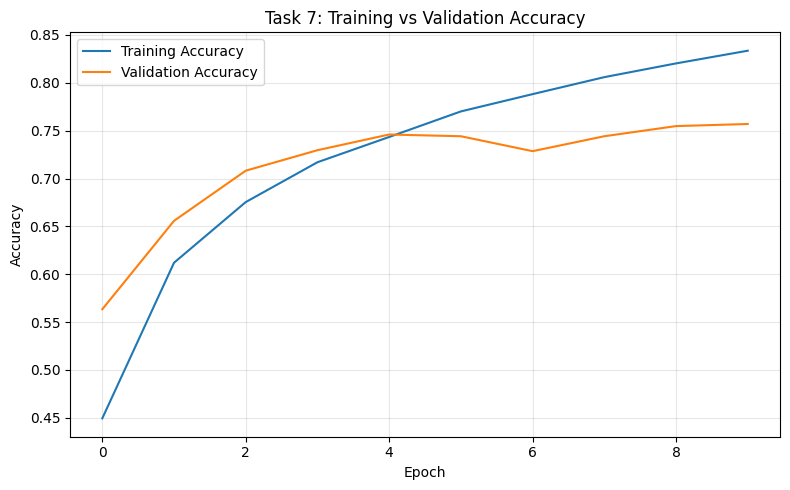

Saved: ./plots/task7_accuracy_curve.png


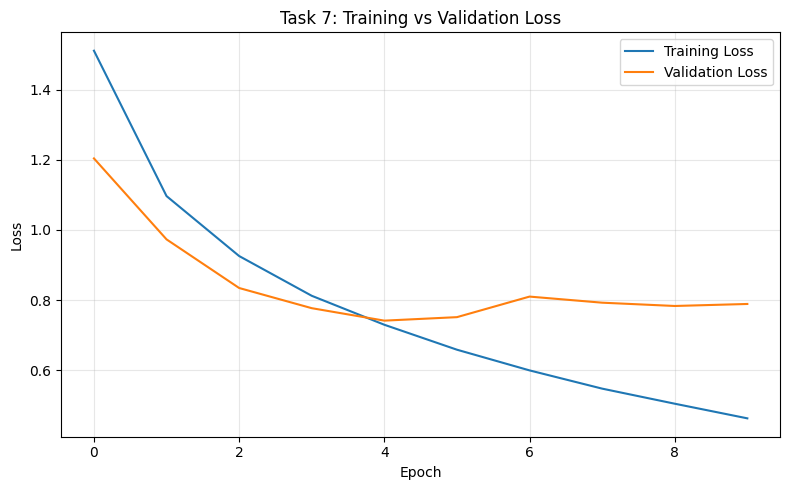

Saved: ./plots/task7_loss_curve.png


In [11]:
# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 7: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()
acc_path = os.path.join(PLOTS_DIR, 'task7_accuracy_curve.png')
plt.tight_layout()
plt.savefig(acc_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', acc_path)

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Task 7: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
loss_path = os.path.join(PLOTS_DIR, 'task7_loss_curve.png')
plt.tight_layout()
plt.savefig(loss_path, dpi=130, bbox_inches='tight')
plt.show()
print('Saved:', loss_path)

## Task 8: Provide Analysis
Short paragraph about:
- CNN performance
- Why accuracy is high/low
- Improvements

In [12]:
val_gap = final_train_acc - final_val_acc
if test_acc >= 0.70:
    performance_level = 'good'
elif test_acc >= 0.55:
    performance_level = 'moderate'
else:
    performance_level = 'low'

analysis_paragraph = (
    f"The CNN achieved {performance_level} performance on CIFAR-10 with test accuracy "
    f"of {test_acc:.4f} after {EPOCHS} epochs. "
    f"Training accuracy was {final_train_acc:.4f} and validation accuracy was {final_val_acc:.4f} "
    f"(gap={val_gap:.4f}), which indicates {'limited overfitting' if val_gap < 0.08 else 'noticeable overfitting'}. "
    f"Because CIFAR-10 is a multi-class natural image dataset, accuracy can stay moderate with short training "
    f"or smaller architectures. Improvements can include deeper CNN blocks, stronger data augmentation, "
    f"learning-rate scheduling, tuned dropout, and training for more epochs. Architecture B uses three convolutional blocks with a deeper dense head and dropout."
)

print(analysis_paragraph)

analysis_path = os.path.join(PLOTS_DIR, 'task8_analysis.txt')
with open(analysis_path, 'w', encoding='utf-8') as f:f.write(analysis_paragraph + '')
print('Saved:', analysis_path)

The CNN achieved good performance on CIFAR-10 with test accuracy of 0.7424 after 10 epochs. Training accuracy was 0.8336 and validation accuracy was 0.7570 (gap=0.0766), which indicates limited overfitting. Because CIFAR-10 is a multi-class natural image dataset, accuracy can stay moderate with short training or smaller architectures. Improvements can include deeper CNN blocks, stronger data augmentation, learning-rate scheduling, tuned dropout, and training for more epochs. Architecture B uses three convolutional blocks with a deeper dense head and dropout.
Saved: ./plots/task8_analysis.txt


## Generate `Lab_Report_6.md` and `Lab_Report_6.html`
Run the next cell after training/evaluation to export report files with your actual results.

In [15]:
import os
from datetime import datetime

# Ensure output dirs exist
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

report_md = f"""# Lab Report 6: Implementing a CNN on CIFAR-10

---

## Objective
Implement and evaluate a CNN on CIFAR-10 by completing all required tasks: data exploration, preprocessing,
model design, training, evaluation, predictions, plotting, and analysis.

## Task 1: Load and Explore CIFAR-10
- Dataset shapes displayed in notebook output
- Class names visualized
- 10 sample images shown

![Task 1 Sample Images](plots/task1_sample_images.png)

## Task 2: Preprocess Data
- Pixel values normalized to [0, 1]
- Labels kept as sparse integer classes (one-hot optional with sparse loss)

## Task 3: CNN Model
Model includes Conv layers, ReLU, MaxPooling, Dropout, Dense, and Softmax output.

## Task 4: Training (10 Epochs)
- Final training accuracy: {final_train_acc:.4f}
- Final validation accuracy: {final_val_acc:.4f}
- Final training loss: {final_train_loss:.4f}
- Final validation loss: {final_val_loss:.4f}

## Task 5: Evaluation
- Test accuracy: {test_acc:.4f}
- Test loss: {test_loss:.4f}

![Confusion Matrix](plots/task5_confusion_matrix.png)

### Classification Report
```text
{report_text}
```

## Task 6: Predictions
Five random test images with actual and predicted labels:

![Random Predictions](plots/task6_random_predictions.png)

## Task 7: Required Plots
![Training vs Validation Accuracy](plots/task7_accuracy_curve.png)
![Training vs Validation Loss](plots/task7_loss_curve.png)

## Task 8: Analysis
{analysis_paragraph}

## Conclusion
The required Lab 06 pipeline was implemented end-to-end on Google Colab and validated with quantitative metrics and visual diagnostics.
"""

# Use a plain template string for HTML to avoid f-string brace issues with CSS.
report_html_template = """<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8'>
  <title>Lab Report 6 - __NAME__</title>
  <style>
    body {
      font-family: Arial, sans-serif;
      margin: 28px;
      line-height: 1.5;
      color: #111;
    }
    h1, h2, h3 {
      margin-top: 24px;
    }
    img {
      max-width: 900px;
      width: 100%;
      border: 1px solid #ddd;
      margin: 8px 0 18px;
    }
    pre {
      background: #f4f4f4;
      padding: 12px;
      overflow-x: auto;
      white-space: pre-wrap;
    }
    .meta {
      margin: 0 0 12px;
    }
  </style>
</head>
<body>
  <h1>Lab Report 6: Implementing a CNN on CIFAR-10</h1>
  <p class='meta'><strong>Course Code:</strong> COMP-341L<br>
  <strong>Course Name:</strong> Artificial Neural Networks Lab<br>
  <strong>Lab Number:</strong> 6<br>
  <strong>Date:</strong> __DATE__<br>
  <strong>Name:</strong> __NAME__<br>
  <strong>Roll Number:</strong> __ROLL__<br>
  <strong>Section:</strong> __SECTION__</p>

  <h2>Objective</h2>
  <p>Implement and evaluate a CNN on CIFAR-10 by completing all required tasks from the manual.</p>

  <h2>Task 1: Load and Explore</h2>
  <img src='plots/task1_sample_images.png' alt='Task 1 sample images'>

  <h2>Task 2: Preprocess</h2>
  <p>Images normalized to [0, 1]. Labels stored as sparse integer classes for sparse categorical loss.</p>

  <h2>Task 3: CNN Model</h2>
  <p>Architecture includes convolution, ReLU, max pooling, dropout, dense, and softmax output layers.</p>

  <h2>Task 4: Training</h2>
  <ul>
    <li>Final training accuracy: __FINAL_TRAIN_ACC__</li>
    <li>Final validation accuracy: __FINAL_VAL_ACC__</li>
    <li>Final training loss: __FINAL_TRAIN_LOSS__</li>
    <li>Final validation loss: __FINAL_VAL_LOSS__</li>
  </ul>

  <h2>Task 5: Evaluation</h2>
  <p>Test accuracy: __TEST_ACC__<br>Test loss: __TEST_LOSS__</p>
  <img src='plots/task5_confusion_matrix.png' alt='Confusion matrix'>
  <h3>Classification Report</h3>
  <pre>__REPORT_TEXT__</pre>

  <h2>Task 6: Predictions</h2>
  <img src='plots/task6_random_predictions.png' alt='Random predictions'>

  <h2>Task 7: Plots</h2>
  <img src='plots/task7_accuracy_curve.png' alt='Accuracy curve'>
  <img src='plots/task7_loss_curve.png' alt='Loss curve'>

  <h2>Task 8: Analysis</h2>
  <p>__ANALYSIS__</p>

  <h2>Conclusion</h2>
  <p>The required Lab 06 workflow was implemented on Google Colab and evaluated with standard classification metrics and plots.</p>
</body>
</html>
"""

report_html = (
    report_html_template
    .replace('__DATE__', datetime.now().strftime('%B %d, %Y'))
    .replace('__NAME__', 'Zarmeena Jawad')
    .replace('__ROLL__', 'B23F0115AI125')
    .replace('__SECTION__', 'AI Red')
    .replace('__FINAL_TRAIN_ACC__', f"{final_train_acc:.4f}")
    .replace('__FINAL_VAL_ACC__', f"{final_val_acc:.4f}")
    .replace('__FINAL_TRAIN_LOSS__', f"{final_train_loss:.4f}")
    .replace('__FINAL_VAL_LOSS__', f"{final_val_loss:.4f}")
    .replace('__TEST_ACC__', f"{test_acc:.4f}")
    .replace('__TEST_LOSS__', f"{test_loss:.4f}")
    .replace('__REPORT_TEXT__', report_text)
    .replace('__ANALYSIS__', analysis_paragraph)
)

md_path = os.path.join(BASE_DIR, 'Lab_Report_6.md')
html_path = os.path.join(BASE_DIR, 'Lab_Report_6.html')

with open(md_path, 'w', encoding='utf-8') as f:
    f.write(report_md)
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(report_html)

print('Saved:', os.path.abspath(md_path))
print('Saved:', os.path.abspath(html_path))
print('Plots currently in directory:')
for fn in sorted(os.listdir(PLOTS_DIR)):
    print(' -', fn)


Saved: /content/Lab_Report_6.md
Saved: /content/Lab_Report_6.html
Plots currently in directory:
 - task1_sample_images.png
 - task5_classification_report.txt
 - task5_confusion_matrix.png
 - task6_random_predictions.png
 - task7_accuracy_curve.png
 - task7_loss_curve.png
 - task8_analysis.txt


In [ ]:
import os
print(sorted(os.listdir(PLOTS_DIR)))
print(os.path.exists(os.path.join(BASE_DIR, "Lab_Report_6.md")))
print(os.path.exists(os.path.join(BASE_DIR, "Lab_Report_6.html")))

In [16]:
# Optional: Zip deliverables for download from Colab.
# import shutil
# shutil.make_archive('Lab_6_Deliverables', 'zip', BASE_DIR)
# print('Created Lab_6_Deliverables.zip')